In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
torch.manual_seed(42)
os.makedirs('../models', exist_ok=True)

print("Setup complete.")

Setup complete.


In [5]:
DATA_PATH = '../data/'

normal_df = pd.read_csv(f'{DATA_PATH}normal3.csv', header=None, names=['raw', 'baseline', 'delta', 'current'])
slowed_df = pd.read_csv(f'{DATA_PATH}slowed3.csv', header=None, names=['raw', 'baseline', 'delta', 'current'])
fast_df   = pd.read_csv(f'{DATA_PATH}spike_data_trimmed.csv',   header=None, names=['raw', 'baseline', 'delta', 'current'])

print(f"Normal : {normal_df.shape}")
print(f"Slowed : {slowed_df.shape}")
print(f"Fast   : {fast_df.shape}")

Normal : (1280, 4)
Slowed : (1280, 4)
Fast   : (1280, 4)


In [6]:
print("\n--- Basic statistics for 'current' column ---")
print("Normal:\n", normal_df['current'].describe())
print("\nSlowed:\n", slowed_df['current'].describe())
print("\nFast:\n", fast_df['current'].describe())

# Class counts before windowing
n_normal = len(normal_df)
n_slowed = len(slowed_df)
n_fast   = len(fast_df)
total = n_normal + n_slowed + n_fast

print("\n--- Raw sample distribution ---")
print(f"Normal : {n_normal:6d} ({100*n_normal/total:.1f}%)")
print(f"Slowed : {n_slowed:6d} ({100*n_slowed/total:.1f}%)")
print(f"Fast   : {n_fast:6d} ({100*n_fast/total:.1f}%)")


--- Basic statistics for 'current' column ---
Normal:
 count    1280.000000
mean        4.059477
std         2.333121
min        -0.100000
25%         1.697500
50%         4.780000
75%         6.040000
max         8.130000
Name: current, dtype: float64

Slowed:
 count    1280.00000
mean        9.31150
std         3.69592
min         0.42000
25%         6.51000
50%         9.63500
75%        12.20250
max        18.73000
Name: current, dtype: float64

Fast:
 count    1280.000000
mean        3.776063
std         4.177323
min        -0.130000
25%         0.667500
50%         3.820000
75%         5.860000
max        81.710000
Name: current, dtype: float64

--- Raw sample distribution ---
Normal :   1280 (33.3%)
Slowed :   1280 (33.3%)
Fast   :   1280 (33.3%)


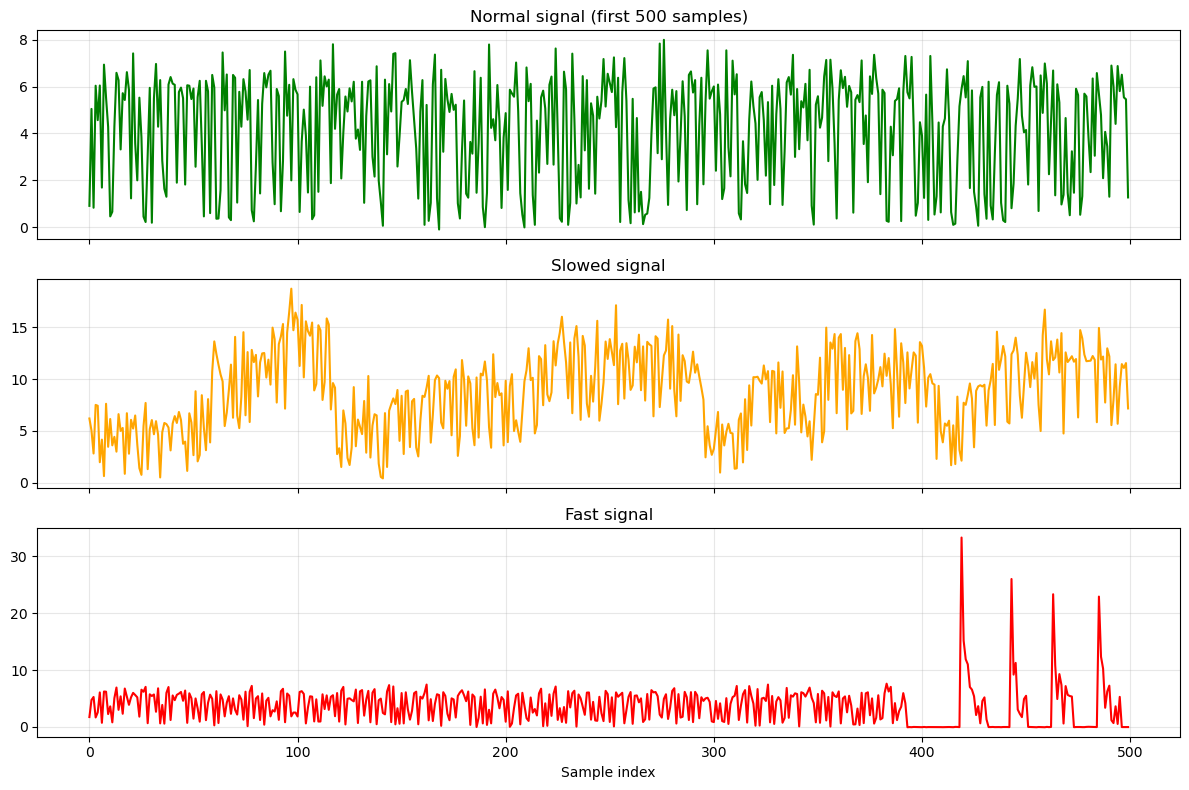

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(normal_df['current'].values[:500], color='green')
axes[0].set_title('Normal signal (first 500 samples)')
axes[0].grid(alpha=0.3)

axes[1].plot(slowed_df['current'].values[:500], color='orange')
axes[1].set_title('Slowed signal')
axes[1].grid(alpha=0.3)

axes[2].plot(fast_df['current'].values[:500], color='red')
axes[2].set_title('Fast signal')
axes[2].grid(alpha=0.3)
axes[2].set_xlabel('Sample index')

plt.tight_layout()
plt.show()

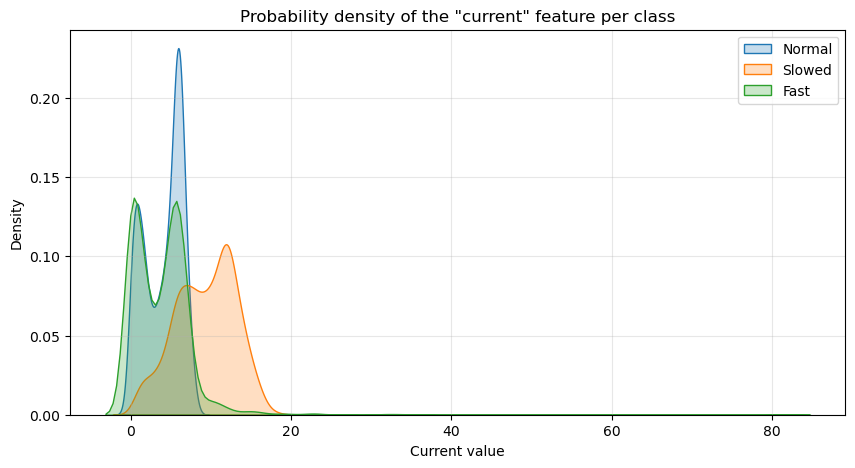

In [8]:
plt.figure(figsize=(10, 5))
sns.kdeplot(normal_df['current'], label='Normal', shade=True)
sns.kdeplot(slowed_df['current'], label='Slowed', shade=True)
sns.kdeplot(fast_df['current'],   label='Fast',   shade=True)
plt.title('Probability density of the "current" feature per class')
plt.xlabel('Current value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
WINDOW_SIZE = 128

def create_windows(data, window_size):
    windows = []
    for i in range(len(data) - window_size + 1):
        windows.append(data[i:i+window_size])
    return np.array(windows)

X = np.vstack([
    create_windows(normal_df['current'].values, WINDOW_SIZE),
    create_windows(slowed_df['current'].values, WINDOW_SIZE),
    create_windows(fast_df['current'].values,   WINDOW_SIZE)
])

y = np.hstack([
    np.zeros(len(normal_df) - WINDOW_SIZE + 1),
    np.ones(len(slowed_df) - WINDOW_SIZE + 1),
    2 * np.ones(len(fast_df) - WINDOW_SIZE + 1)
])

# Shuffle
indices = np.random.permutation(len(X))
X, y = X[indices], y[indices]

print(f"Total windows: {X.shape[0]}, each of length {X.shape[1]}")
print("Class distribution in windows:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {int(u)}: {c} ({100*c/len(y):.1f}%)")

Total windows: 3459, each of length 128
Class distribution in windows:
  Class 0: 1153 (33.3%)
  Class 1: 1153 (33.3%)
  Class 2: 1153 (33.3%)


In [10]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

# Scale each window independently
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(-1, WINDOW_SIZE)
X_val   = scaler.transform(X_val.reshape(-1, 1)).reshape(-1, WINDOW_SIZE)
X_test  = scaler.transform(X_test.reshape(-1, 1)).reshape(-1, WINDOW_SIZE)

joblib.dump(scaler, '../models/scaler.joblib')

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print("Training class counts:", np.bincount(y_train.astype(int)))
print("Validation class counts:", np.bincount(y_val.astype(int)))
print("Test class counts:", np.bincount(y_test.astype(int)))

Train: 2421, Val: 346, Test: 692
Training class counts: [807 807 807]
Validation class counts: [116 115 115]
Test class counts: [230 231 231]


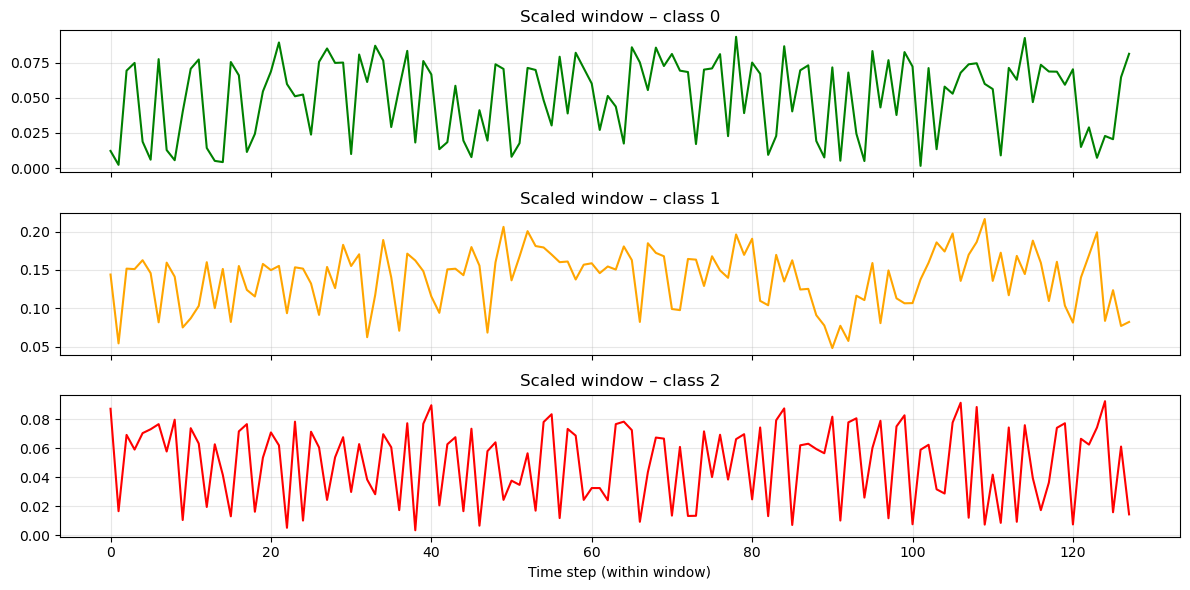

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

for ax, label, color in zip(axes, [0,1,2], ['green','orange','red']):
    idx = np.where(y_train == label)[0][0]
    ax.plot(X_train[idx], color=color)
    ax.set_title(f'Scaled window – class {int(label)}')
    ax.grid(alpha=0.3)

plt.xlabel('Time step (within window)')
plt.tight_layout()
plt.show()

In [12]:
class MotorFaultCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.15)

        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)
        self.dropout2 = nn.Dropout(0.2)

        self.conv3 = nn.Conv1d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(2)
        self.dropout3 = nn.Dropout(0.3)

        self.fc1 = nn.Linear(128 * 16, 64)
        self.bn_fc1 = nn.BatchNorm1d(64)
        self.dropout_fc = nn.Dropout(0.4)
        self.fc2 = nn.Linear(64, 3)   # 3 classes

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout1(x)
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout2(x)
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout3(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        return x

model = MotorFaultCNN()
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 167,171


In [13]:
BATCH_SIZE = 32

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train, dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_train, dtype=torch.long)
    ),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_val, dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_val, dtype=torch.long)
    ),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test, dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_test, dtype=torch.long)
    ),
    batch_size=BATCH_SIZE, shuffle=False
)

In [14]:
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_val_acc = 0
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            train_total += batch_y.size(0)
            train_correct += (pred == batch_y).sum().item()

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                val_total += batch_y.size(0)
                val_correct += (pred == batch_y).sum().item()

        val_acc = 100 * val_correct / val_total
        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), '../models/best_model.pth')
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= 15:
            break

    model.load_state_dict(torch.load('../models/best_model.pth'))
    return model, best_val_acc

model, best_val_acc = train_model(model, train_loader, val_loader)
print(f"Best validation accuracy: {best_val_acc:.2f}%")

Best validation accuracy: 100.00%


PyTorch Test Accuracy: 100.00%


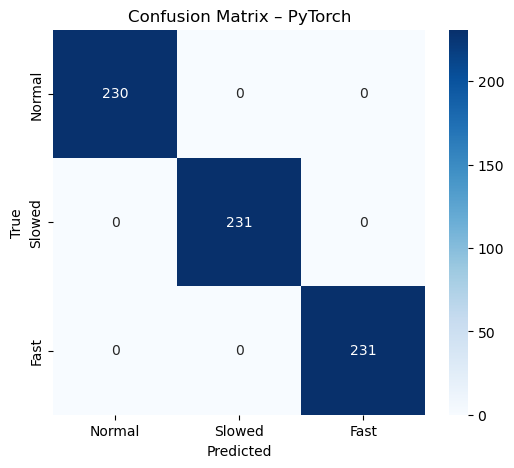


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       230
      Slowed       1.00      1.00      1.00       231
        Fast       1.00      1.00      1.00       231

    accuracy                           1.00       692
   macro avg       1.00      1.00      1.00       692
weighted avg       1.00      1.00      1.00       692



In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())

accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
print(f"PyTorch Test Accuracy: {accuracy:.2f}%")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Slowed','Fast'],
            yticklabels=['Normal','Slowed','Fast'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – PyTorch')
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Normal','Slowed','Fast']))

In [16]:
import onnx2tf
import shutil
import tensorflow as tf

# Clean previous exports
for path in ["../models/model_tf", "../models/model_tf_quant"]:
    if os.path.exists(path):
        shutil.rmtree(path)

dummy_input = torch.randn(1, 1, 128)
onnx_path = "../models/model.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=11,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)
print("✅ Exported to ONNX")

E0000 00:00:1783835497.203269  208902 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783835497.205575  208902 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783835497.212261  208902 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783835497.212268  208902 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783835497.212269  208902 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783835497.212270  208902 computation_placer.cc:177] computation placer already registered. Please check linka

[torch.onnx] Obtain model graph for `MotorFaultCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MotorFaultCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnx/version_converter.py", line 39, in convert_vers

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✅ Exported to ONNX


In [17]:
onnx2tf.convert(
    input_onnx_file_path=onnx_path,
    output_folder_path="../models/model_tf",
    output_signaturedefs=True,
)
print("✅ Converted to TensorFlow SavedModel")

# Quick verification
saved_model = tf.saved_model.load("../models/model_tf")
concrete_func = saved_model.signatures['serving_default']
print(f"SavedModel input shape: {concrete_func.inputs[0].shape}")


Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Concat     │ 1              │ 1                │
│ Constant   │ 11             │ 11               │
│ Conv       │ 3              │ 3                │
│ Gemm       │ 2              │ 2                │
│ MaxPool    │ 3              │ 3                │
│ Relu       │ 4              │ 4                │
│ Reshape    │ 1              │ 1                │
│ Shape      │ 1              │ 1                │
│ Model Size │ 666.4KiB       │ 653.2KiB         │
└────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ 

W0000 00:00:1783835512.800781  208902 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1783835512.800805  208902 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1783835512.804315  208902 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


Float32 tflite output complete!
Float16 tflite output complete!
✅ Converted to TensorFlow SavedModel
SavedModel input shape: (None, 128, 1)


W0000 00:00:1783835513.412693  208902 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1783835513.412708  208902 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [18]:
# ---- FP32 ----
converter = tf.lite.TFLiteConverter.from_saved_model("../models/model_tf")
tflite_fp32 = converter.convert()
with open("../models/model_fp32.tflite", "wb") as f:
    f.write(tflite_fp32)
print("✅ FP32 TFLite saved")

# ---- FP16 ----
converter = tf.lite.TFLiteConverter.from_saved_model("../models/model_tf")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_fp16 = converter.convert()
with open("../models/model_fp16.tflite", "wb") as f:
    f.write(tflite_fp16)
print("✅ FP16 TFLite saved")

# ---- INT8 (with representative dataset) ----
def representative_dataset():
    for _ in range(100):
        idx = np.random.randint(0, len(X_train))
        yield [X_train[idx].reshape(1, 128, 1).astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_saved_model("../models/model_tf")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32   # keep float input for ease
converter.inference_output_type = tf.float32  # keep float output
tflite_int8 = converter.convert()
with open("../models/model_int8.tflite", "wb") as f:
    f.write(tflite_int8)
print("✅ INT8 TFLite saved")

W0000 00:00:1783835536.834161  208902 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1783835536.834185  208902 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


✅ FP32 TFLite saved


W0000 00:00:1783835537.257329  208902 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1783835537.257348  208902 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


✅ FP16 TFLite saved
✅ INT8 TFLite saved


W0000 00:00:1783835537.681756  208902 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1783835537.681774  208902 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


In [19]:
def evaluate_tflite(tflite_path, X_test, y_test):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()
    out = interpreter.get_output_details()

    preds = []
    for window in X_test:
        input_data = window.reshape(1, 128, 1).astype(np.float32)
        interpreter.set_tensor(inp[0]['index'], input_data)
        interpreter.invoke()
        output = interpreter.get_tensor(out[0]['index'])[0]
        preds.append(np.argmax(output))

    return 100 * np.mean(np.array(preds) == y_test)

print("TFLite accuracies:")
acc_fp32 = evaluate_tflite("../models/model_fp32.tflite", X_test, y_test)
acc_fp16 = evaluate_tflite("../models/model_fp16.tflite", X_test, y_test)
acc_int8 = evaluate_tflite("../models/model_int8.tflite", X_test, y_test)

print(f"FP32 : {acc_fp32:.2f}%")
print(f"FP16 : {acc_fp16:.2f}%")
print(f"INT8 : {acc_int8:.2f}%")

TFLite accuracies:
FP32 : 100.00%
FP16 : 100.00%
INT8 : 100.00%


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


True label  : Fast
Predicted   : Fast
Confidences : {'Normal': 0.004107556, 'Slowed': 0.0020594117, 'Fast': 0.99383307}


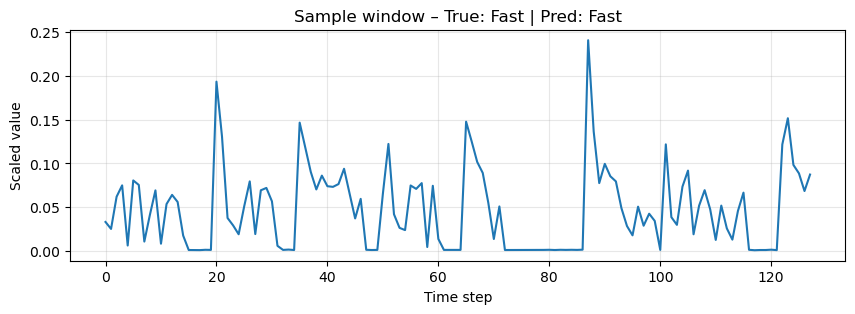

In [20]:
sample_idx = 0
sample_window = X_test[sample_idx]
sample_label = y_test[sample_idx]

# Scale already done, just reshape
input_data = sample_window.reshape(1, 128, 1).astype(np.float32)

# Pick a model (e.g., INT8)
interpreter = tf.lite.Interpreter(model_path="../models/model_int8.tflite")
interpreter.allocate_tensors()
inp = interpreter.get_input_details()
out = interpreter.get_output_details()
interpreter.set_tensor(inp[0]['index'], input_data)
interpreter.invoke()
output = interpreter.get_tensor(out[0]['index'])[0]

probs = np.exp(output) / np.sum(np.exp(output))
pred_class = np.argmax(probs)

class_names = ['Normal', 'Slowed', 'Fast']
print(f"True label  : {class_names[int(sample_label)]}")
print(f"Predicted   : {class_names[pred_class]}")
print(f"Confidences : {dict(zip(class_names, probs))}")

# Plot the window with prediction
plt.figure(figsize=(10,3))
plt.plot(sample_window)
plt.title(f"Sample window – True: {class_names[int(sample_label)]} | Pred: {class_names[pred_class]}")
plt.xlabel('Time step')
plt.ylabel('Scaled value')
plt.grid(alpha=0.3)
plt.show()

Model sizes (MB):
  FP32: 0.64 MB
  FP16: 0.33 MB
  INT8: 0.18 MB


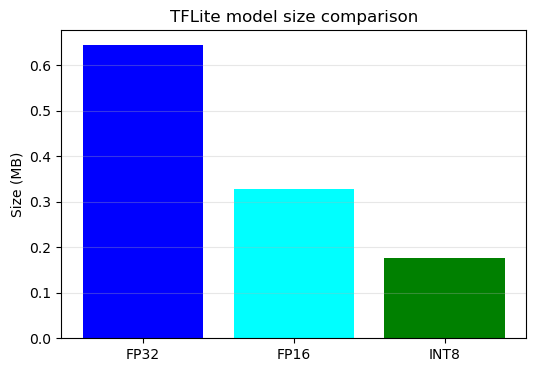

In [21]:
import os

def get_size(path):
    return os.path.getsize(path) / (1024 * 1024)  # MB

sizes = {
    'FP32': get_size("../models/model_fp32.tflite"),
    'FP16': get_size("../models/model_fp16.tflite"),
    'INT8': get_size("../models/model_int8.tflite")
}

print("Model sizes (MB):")
for name, sz in sizes.items():
    print(f"  {name}: {sz:.2f} MB")

plt.figure(figsize=(6,4))
plt.bar(sizes.keys(), sizes.values(), color=['blue','cyan','green'])
plt.ylabel('Size (MB)')
plt.title('TFLite model size comparison')
plt.grid(axis='y', alpha=0.3)
plt.show()